## Real estate data cleaning with Pandas for efficient analysis
This is a real dataset that was downloaded using web scraping techniques. The data contains records from Fotocasa, one of the most popular real estate websites in Spain. Please do not perform web scraping unless it is for academic purposes.

The dataset was downloaded a few years ago by Henry Navarro, and no economic benefit was obtained from it.

It contains thousands of real house listings published on the website www.fotocasa.com. Your goal is to extract as much information as possible with the data science knowledge you have acquired so far.

Let's get started!

- First, let's read and explore the dataset.

In [1]:
# Step 0. Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1. Load data
df_raw = pd.read_csv("../real_estate.csv",sep=";")
df_raw.sample(10)

,Unnamed: 0,id_realEstates,isNew,realEstate_name,phone_realEstate,url_inmueble,rooms,bathrooms,surface,price,...,level4Id,level5Id,level6Id,level7Id,level8Id,accuracy,latitude,longitude,zipCode,customZone
3873,3874,150365317,False,primer nivel,912788139.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,6.0,4.0,455.0,799000,...,0,0,0,0,0,0,"40,5918","-3,58939",NaN,NaN
5284,5285,153989077,False,infocasa consulting,911360461.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,93.0,248000,...,0,0,0,0,0,0,"40,4041057864376","-3,65169578643763",NaN,NaN
5140,5141,153628087,False,home casa,912177029.0,https://www.fotocasa.es/es/comprar/vivienda/el...,3.0,1.0,74.0,114900,...,0,0,0,0,0,1,"40,46325","-3,46362",NaN,NaN
13092,13093,152924563,False,lecasa,911790671.0,https://www.fotocasa.es/es/comprar/vivienda/vi...,2.0,1.0,NaN,166000,...,0,0,0,0,0,0,"40,24884","-3,82875",NaN,NaN
9816,9817,151128525,False,rivas premium,912179687.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,4.0,2.0,126.0,281700,...,0,0,0,0,0,1,"40,3791397","-3,5370988",NaN,NaN
6058,6059,150325409,False,inmodama consulting inmobiliario,911366763.0,https://www.fotocasa.es/es/comprar/vivienda/ti...,5.0,3.0,230.0,285000,...,0,0,0,0,0,0,"40,6977239235447","-3,93831302026124",NaN,NaN
12390,12391,153434358,False,whan house consulting,925630418.0,https://www.fotocasa.es/es/comprar/vivienda/ho...,4.0,2.0,167.0,729900,...,0,0,0,0,0,0,"40,4294645","-3,7045518",NaN,NaN
4184,4185,153366775,False,promociones habitat sa,910302643.0,https://www.fotocasa.es/vivienda/madrid-capita...,3.0,2.0,139.0,260000,...,0,0,0,0,0,1,"40,37809","-3,47885",NaN,NaN
11563,11564,151613302,False,unna madrid,912780846.0,https://www.fotocasa.es/es/comprar/vivienda/va...,1.0,1.0,45.0,239000,...,0,0,0,0,0,1,"40,41019","-3,7134",NaN,NaN
5451,5452,150261228,False,promotasa,914894395.0,https://www.fotocasa.es/es/comprar/vivienda/cu...,2.0,1.0,53.0,123000,...,0,0,0,0,0,0,"40,35003","-3,54662",NaN,NaN


In [3]:
# Step 2. See info
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15335 entries, 0 to 15334
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        15335 non-null  int64  
 1   id_realEstates    15335 non-null  int64  
 2   isNew             15335 non-null  bool   
 3   realEstate_name   15325 non-null  object 
 4   phone_realEstate  14541 non-null  float64
 5   url_inmueble      15335 non-null  object 
 6   rooms             14982 non-null  float64
 7   bathrooms         14990 non-null  float64
 8   surface           14085 non-null  float64
 9   price             15335 non-null  int64  
 10  date              15335 non-null  object 
 11  description       15193 non-null  object 
 12  address           15335 non-null  object 
 13  country           15335 non-null  object 
 14  level1            15335 non-null  object 
 15  level2            15335 non-null  object 
 16  level3            15335 non-null  object

In [4]:
#Step 3. Preprossesing
df_baking = df_raw.copy()
df_baking = df_baking.iloc[:,1:-2]
df_baking["date"] = pd.to_datetime(df_baking["date"],errors="coerce")
df_baking.columns = df_baking.columns.str.lower()
df_baking = df_baking.drop(columns=["country","countryid","level1id","level2id","level3id","level4id","level5id","level6id","level7id","level8id","accuracy"])
df_baking["id_realestates"] = df_baking["id_realestates"].astype("category")
df_baking["phone_realestate"] = df_baking["phone_realestate"].astype("category")
df_baking["realestate_name"] = df_baking["realestate_name"].astype("category")
df_baking["url_inmueble"] = df_baking["url_inmueble"].astype("category")
df_baking["address"] = df_baking["address"].astype("category")
df_baking["description"] = df_baking["description"].astype("category")
df_baking["latitude"] = df_baking["latitude"].str.replace(",",".")
df_baking["latitude"] = df_baking["latitude"].astype(float)
df_baking["longitude"] = df_baking["longitude"].str.replace(",",".")
df_baking["longitude"] = df_baking["longitude"].astype(float)
df_baking.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15335 entries, 0 to 15334
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id_realestates    15335 non-null  category           
 1   isnew             15335 non-null  bool               
 2   realestate_name   15325 non-null  category           
 3   phone_realestate  14541 non-null  category           
 4   url_inmueble      15335 non-null  category           
 5   rooms             14982 non-null  float64            
 6   bathrooms         14990 non-null  float64            
 7   surface           14085 non-null  float64            
 8   price             15335 non-null  int64              
 9   date              683 non-null    datetime64[ns, UTC]
 10  description       15193 non-null  category           
 11  address           15335 non-null  category           
 12  level1            15335 non-null  object             
 13  l

In [9]:
df = df_baking.copy()
df.sample(5,random_state=2025)

,id_realestates,isnew,realestate_name,phone_realestate,url_inmueble,rooms,bathrooms,surface,price,date,...,level2,level3,level4,level5,level6,level7,level8,upperlevel,latitude,longitude
11956,153704529,False,habita mad,918007061.0,https://www.fotocasa.es/es/comprar/vivienda/gu...,3.0,1.0,72.0,214000,NaT,...,Madrid,"Madrid, Zona de",NaN,Madrid Capital,NaN,Hortaleza,Canillas,Canillas,40.464490,-3.632650
7285,150530836,False,desarrollo de viviendas nueva ciudad,916358709.0,https://www.fotocasa.es/vivienda/alcala-de-hen...,3.0,2.0,112.0,243800,NaT,...,Madrid,Zona Sur de Madrid,"Parla, Zona de",Parla,NaN,Centro,NaN,Centro,40.237680,-3.774230
14035,153921873,False,garsierra,912179623.0,https://www.fotocasa.es/es/comprar/vivienda/ti...,1.0,2.0,72.0,85000,NaT,...,Madrid,Corredor del Henares,"Camarma de Esteruelas, Zona de",Camarma de Esteruelas,NaN,NaN,NaN,Camarma de Esteruelas,40.550675,-3.377295
10823,150512853,False,covibarges,912175971.0,https://www.fotocasa.es/vivienda/arganda-del-r...,3.0,2.0,107.0,255000,NaT,...,Madrid,Madrid Sureste - Cuenca Tajuña,"Rivas-Vaciamadrid, Zona de",Rivas-vaciamadrid,NaN,Rivas Urbanizaciones,NaN,Rivas Urbanizaciones,40.382190,-3.530690
5778,148949209,False,urban,912780256.0,https://www.fotocasa.es/es/comprar/vivienda/pa...,4.0,4.0,NaN,439000,NaT,...,Madrid,Zona Suroeste,"Brunete, Zona de",Brunete,NaN,NaN,NaN,Brunete,40.397230,-3.998940


Exercise 01. What is the most expensive house in the entire dataset? (★☆☆)

Print the address and price of the selected house. 

In [ ]:
df.sort_values(by="price",ascending=False)[["address","price"]].head(1).head(1)

,address,price
13110,El Escorial,8500000


Exercise 02. What is the cheapest house in the dataset? (★☆☆)

This exercise is similar to the previous one, except now we are looking for the house with the lowest price. Remember to print the address and price of the selected house. 

In [ ]:
df[df["price"] != 0].sort_values(by="price",ascending=True)[["address","price"]].head(1)

,address,price
7491,"Berlin, Coslada",600



Exercise 03. What is the largest and smallest house in the dataset? (★☆☆)

Print the address and area of the selected houses. For example:

The largest house is located at Calle Gran Vía, Nº38, and its area is 5000 square meters.

The smallest house is located at Calle Mayor, Nº12, and its area is 200 square meters.

This exercise is similar to the previous one, but we are looking for the largest and smallest houses based on their area.


In [15]:
display(df.sort_values(by="surface", ascending=True)[["address","surface"]].head(1))
display(df.sort_values(by="surface", ascending=False)[["address","surface"]].head(1))

,address,surface
498,"Calle Amparo, Madrid Capital",15.0


,address,surface
6794,Sevilla la Nueva,249000.0


In [ ]:

Exercise 04. How many unique populations are in the dataset? (★☆☆)

Count the number of unique populations in the 'level5' column and print the names of the populations separated by commas. For example:

> print(populations)

population1, population2, population3, ...


In [ ]:
level5_list = df["level5"].unique().tolist()
level5_list_count = df["level5"].nunique()
print(f"hay {level5_list_count} ciudades y estas son: {","join(level5_list)}")

In [ ]:
df.isna()

In [ ]:
df.dropna(subset=["surface"])

,id_realestates,isnew,realestate_name,phone_realestate,url_inmueble,rooms,bathrooms,surface,price,date,...,level2,level3,level4,level5,level6,level7,level8,upperlevel,latitude,longitude


In [25]:
precio_medio = df[df["level5"] == "Arroyomolinos (Madrid)"]["price"].mean()
print(f"el precio promedio en Arroyomolinos (Madrid) es {precio_medio.1f}")

SyntaxError: invalid decimal literal (2033831689.py, line 2)

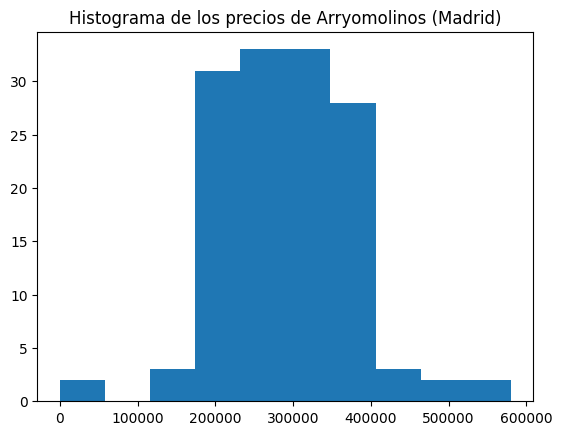

In [26]:
plt.hist(df[df["level5"] == "Arroyomolinos (Madrid)"]["price"])
plt.title("Histograma de los precios de Arryomolinos (Madrid)")
plt.show()

##

In [31]:
city1="Valdemorillo"
city2="Galapagar"
pps_valdemorillo = df.assign(price_per_area=df["price"]/df["surface"]).query("level5 == @city1")["price_per_area"].mean()
pps_galapagar = df.assign(price_per_area=df["price"]/df["surface"]).query("level5 == @city2")["price_per_area"].mean()
print(f"El precio promedio de Valdemorillo es {pps_valdemorillo.f1}")

AttributeError: 'numpy.float64' object has no attribute 'f1'

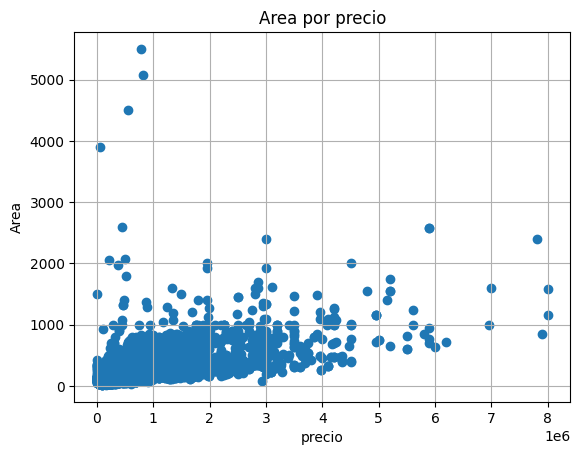

In [37]:
plt.scatter(df[df["surface"] < 10000]["price"],df[df["surface"] < 10000]["surface"])
plt.ylabel("Area")
plt.xlabel("precio")
plt.title("Area por precio")
plt.grid(True)
plt.show()


In [43]:
df.groupby(by="level5").size().sort_values(ascending=False)

level5
 Madrid Capital         6643
Alcalá de Henares        525
Las Rozas de Madrid      383
Móstoles                 325
Getafe                   290
                        ... 
Montejo de la Sierra       1
Lozoya                     1
Pinilla del Valle          1
Rascafría                  1
Piñuécar-gandullas         1
Length: 168, dtype: int64